In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

## Load Data

In [3]:
data=pd.read_csv('emotion_dataset_raw.csv')
data.head(10)
data=data.rename(columns={'Text':'text'})
data.head(5)

,Emotion,text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34792 entries, 0 to 34791
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Emotion  34792 non-null  object
 1   text     34792 non-null  object
dtypes: object(2)
memory usage: 543.8+ KB


In [5]:
data.isnull().sum()

Emotion    0
text       0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(3630)

In [7]:
#Emotion Label Counts:
print('Emotion Label Counts')
print(data['Emotion'].value_counts())

Emotion Label Counts
Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64


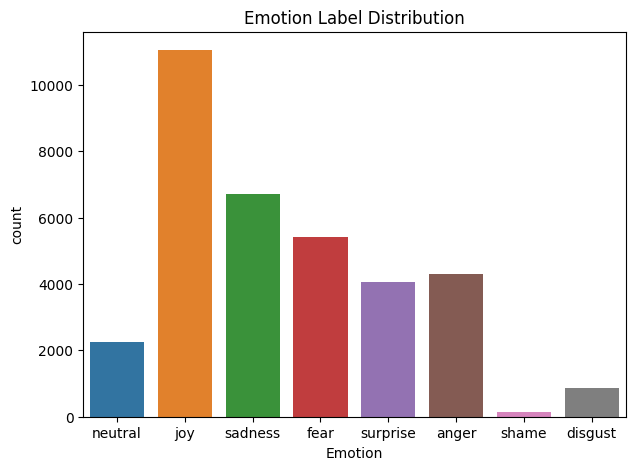

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
# Use countplot for an automatic count of each category
sns.countplot(
    data=data,         # Your DataFrame
    x='Emotion',     # The column you want to count and plot
    hue='Emotion'
)

plt.title('Emotion Label Distribution')
plt.show()

In [8]:
#graph plot


In [9]:
data['text'].fillna('', inplace=True)

C:\Users\formi\AppData\Local\Temp\ipykernel_404\1759347307.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['text'].fillna('', inplace=True)


In [10]:
data['Emotion'].str.lower()

0         neutral
1             joy
2         sadness
3             joy
4             joy
           ...   
34787    surprise
34788         joy
34789       anger
34790        fear
34791     sadness
Name: Emotion, Length: 34792, dtype: object

In [11]:
data['Emotion'].value_counts()

Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64

In [12]:
nltk.download('stopwords')

nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\formi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\formi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Preprocess the Data

In [13]:
#nltk.download('punkt')

In [14]:
def preprocess_text(text):
    #stopwords like-'a','an','the','for',etc.
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    filtered = [word for word in tokens if word.isalnum() and word not in stop_words]
    return ' '.join(filtered)


In [15]:
# Apply preprocessing to the 'text' column
data['processed_text'] = data['text'].apply(preprocess_text)
print(data)

        Emotion                                               text  \
0       neutral                                             Why ?    
1           joy    Sage Act upgrade on my to do list for tommorow.   
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...   
3           joy   Such an eye ! The true hazel eye-and so brill...   
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...   
...         ...                                                ...   
34787  surprise  @MichelGW have you gift! Hope you like it! It'...   
34788       joy  The world didnt give it to me..so the world MO...   
34789     anger                           A man robbed me today .    
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...   
34791   sadness  I think about you baby, and I dream about you ...   

                                          processed_text  
0                                                         
1                         sage act upgrad

In [16]:
# Features and labels
x_texts = data['processed_text']
y_labels = data['Emotion']

In [17]:
# Convert text to numerical features (Bag of Words)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(x_texts)

In [18]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)


In [19]:
#from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
#from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Evaluate the model

In [21]:

#from sklearn.metrics import classification_report

y_pred = model.predict(x_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:

              precision    recall  f1-score   support

       anger       0.63      0.50      0.56       836
     disgust       0.38      0.02      0.05       202
        fear       0.74      0.63      0.68      1104
         joy       0.52      0.86      0.65      2214
     neutral       0.39      0.03      0.06       481
     sadness       0.56      0.56      0.56      1327
       shame       1.00      0.04      0.08        23
    surprise       0.64      0.28      0.39       772

    accuracy                           0.57      6959
   macro avg       0.61      0.37      0.38      6959
weighted avg       0.58      0.57      0.54      6959



In [26]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.5736456387411984

## Predict emotions for new sentences

In [31]:
def predict_emotion(text):
    # Preprocess the text
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    filtered = [word for word in tokens if word.isalnum() and word not in stop_words]
    clean_text = ' '.join(filtered)

    # Transform into vector
    X_input = vectorizer.transform([clean_text])
    y_output = model.predict(X_input)
    
    # Decode the label
    return label_encoder.inverse_transform(y_output)[0]

# Example usage
test_sentence = "What!What!What!I don't believe this.This is so beautiful!"
predicted = predict_emotion(test_sentence)
print(f"\nPredicted emotion: {predicted}")



Predicted emotion: joy
